# Day 3: Exploratory Data Analysis — Telco Customer Churn

Goal: understand who churns and why, using summary statistics and visualizations, before building the dashboard.

## 1. Load cleaned data & summary statistics

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv('telco_churn_cleaned.csv')
df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)
print('Shape:', df.shape)
print('Overall churn rate:', round(df['ChurnFlag'].mean()*100, 1), '%')
df[['tenure','MonthlyCharges','TotalCharges']].describe()

**Observation:** Roughly 1 in 4 customers (22.3%) has churned. Average tenure and monthly charges give us a baseline — now we dig into *which* customers are driving that number.

## 2. Chart 1 — Churn rate by contract type

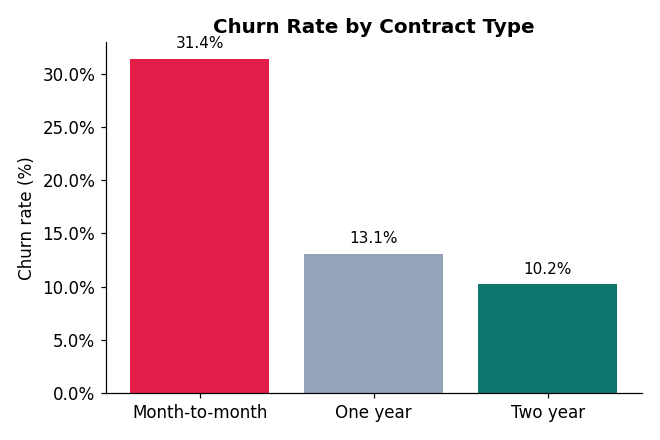

In [1]:
rate = df.groupby('Contract')['ChurnFlag'].mean().reindex(['Month-to-month','One year','Two year'])
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(rate.index, rate.values*100, color=['#E11D48','#94A3B8','#0F766E'])
ax.set_ylabel('Churn rate (%)'); ax.set_title('Churn Rate by Contract Type')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for b, v in zip(bars, rate.values):
    ax.text(b.get_x()+b.get_width()/2, v*100+1, f'{v*100:.1f}%', ha='center')
plt.tight_layout(); plt.show()

**Observation:** Month-to-month customers churn at **31.4%**, roughly **3x** the rate of two-year contract customers (**10.2%**). Contract length is the single strongest lever we have over churn.

## 3. Chart 2 — Churn rate by tenure group

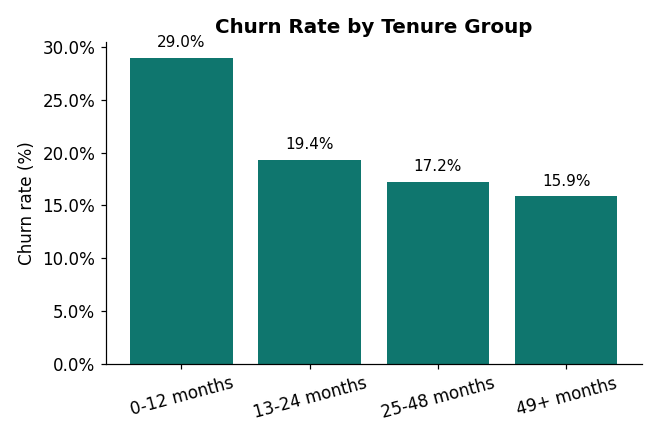

In [1]:
order = ['0-12 months','13-24 months','25-48 months','49+ months']
rate2 = df.groupby('TenureGroup')['ChurnFlag'].mean().reindex(order)
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(rate2.index, rate2.values*100, color='#0F766E')
ax.set_ylabel('Churn rate (%)'); ax.set_title('Churn Rate by Tenure Group')
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); plt.xticks(rotation=15)
for b, v in zip(bars, rate2.values):
    ax.text(b.get_x()+b.get_width()/2, v*100+1, f'{v*100:.1f}%', ha='center')
plt.tight_layout(); plt.show()

**Observation:** New customers (0–12 months) churn at **29.0%**, almost double the rate of customers with 49+ months of tenure (**15.9%**). The first year is the highest-risk window.

## 4. Chart 3 — Monthly charges: retained vs. churned

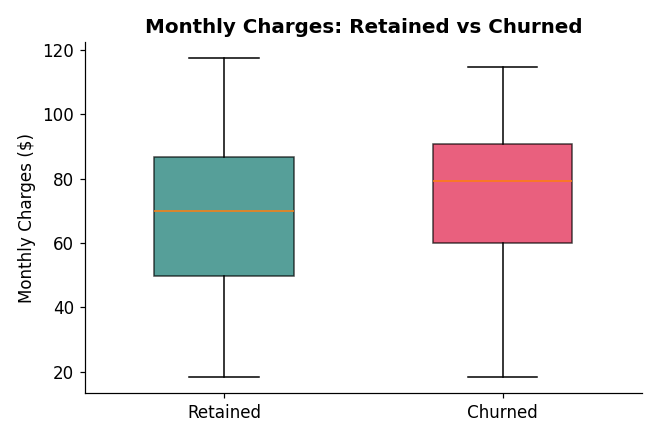

In [1]:
fig, ax = plt.subplots(figsize=(6,4))
data_no = df.loc[df['Churn']=='No', 'MonthlyCharges']
data_yes = df.loc[df['Churn']=='Yes', 'MonthlyCharges']
bp = ax.boxplot([data_no, data_yes], tick_labels=['Retained','Churned'], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], ['#0F766E', '#E11D48']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Monthly Charges ($)'); ax.set_title('Monthly Charges: Retained vs Churned')
plt.tight_layout(); plt.show()

**Observation:** Churned customers skew toward **higher** monthly charges than retained customers — churn isn't concentrated among bargain-plan customers, it's concentrated among customers paying more without matching perceived value.

## 5. Chart 4 — Churn rate by internet service type

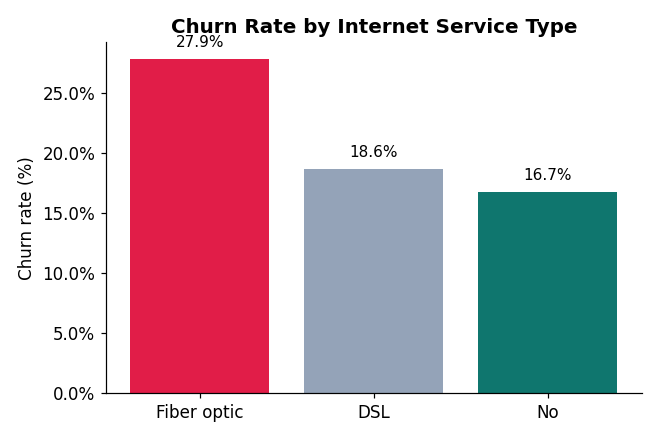

In [1]:
rate4 = df.groupby('InternetService')['ChurnFlag'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(rate4.index, rate4.values*100, color=['#E11D48','#94A3B8','#0F766E'])
ax.set_ylabel('Churn rate (%)'); ax.set_title('Churn Rate by Internet Service Type')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for b, v in zip(bars, rate4.values):
    ax.text(b.get_x()+b.get_width()/2, v*100+1, f'{v*100:.1f}%', ha='center')
plt.tight_layout(); plt.show()

**Observation:** Fiber optic customers churn at **27.9%**, notably higher than DSL (**18.6%**) — worth investigating pricing or service-reliability complaints specific to the fiber product.

## 6. Chart 5 — Churn rate by payment method

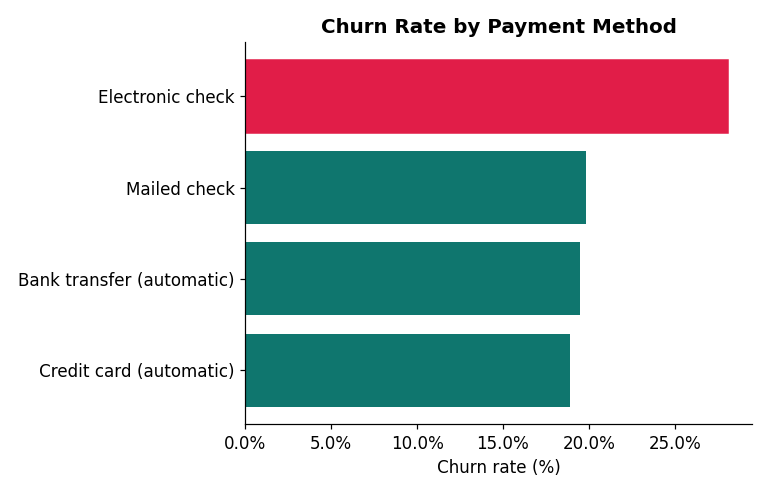

In [1]:
rate5 = df.groupby('PaymentMethod')['ChurnFlag'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.barh(rate5.index[::-1], rate5.values[::-1]*100, color='#0F766E')
bars[-1].set_color('#E11D48')
ax.set_xlabel('Churn rate (%)'); ax.set_title('Churn Rate by Payment Method')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()

**Observation:** Electronic check users churn at **28.1%**, well above automatic payment methods (~19%). Manual payment friction correlates with disengagement — and disengaged customers churn.

## 7. Chart 6 (bonus) — Correlation heatmap

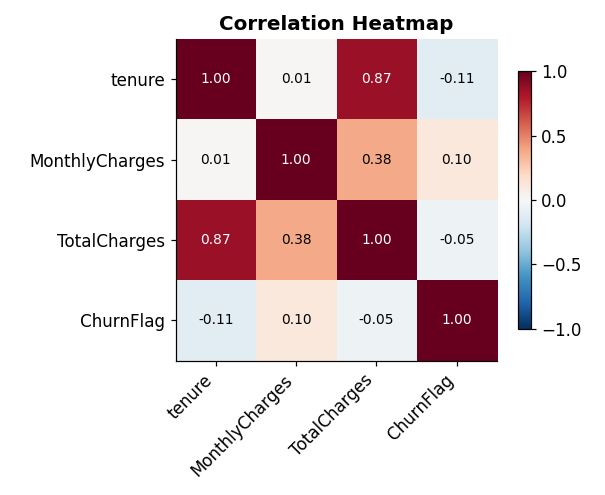

In [1]:
num_df = df[['tenure','MonthlyCharges','TotalCharges','ChurnFlag']]
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(5.5,4.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right'); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                 color='white' if abs(corr.values[i,j])>0.5 else 'black')
ax.set_title('Correlation Heatmap'); fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.show()

**Observation:** `tenure` is negatively correlated with churn while positively correlated with `TotalCharges` (longer-tenured customers have paid more in total, unsurprisingly) — confirming tenure is the variable to focus retention efforts around.

## Summary of EDA Findings

| Driver | Highest-risk segment | Churn rate |
|---|---|---|
| Contract type | Month-to-month | 31.4% |
| Tenure | 0–12 months | 29.0% |
| Internet service | Fiber optic | 27.9% |
| Payment method | Electronic check | 28.1% |

These four findings directly inform the dashboard (Day 4) and the recommendations (Day 5).